# **Experiment Notebook**



In [1]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *

In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
pip install -i https://test.pypi.org/simple/ --extra-index-url https://pypi.org/simple nba-draft-predictor==0.2.5

Looking in indexes: https://test.pypi.org/simple/, https://pypi.org/simple
Note: you may need to restart the kernel to use updated packages.


---
## A. Project Description


In [5]:
# <Student to fill this section>
student_name = "Pranav Sathyababu"
student_id = "25588726"
group_id = "24"

In [6]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [7]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

In [8]:
# Do not modify this code
print_tile(size="h1", key='group_id', value=group_id)

---
## B. Business Understanding

In [9]:
business_use_case_description = """
This project predicts the likelihood that a college or international basketball player will be drafted into the NBA based on performance, efficiency, and contextual attributes. The goal is to prioritize scouting resources, surface undervalued prospects earlier, and support data-driven draft decisions. By producing a ranked list with probabilities, the model helps front-office and scouting teams focus film study and workouts on the highest-upside players while quantifying risk.
"""


In [10]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [11]:
business_objectives = """
Accurate results will provide NBA teams with a reliable, data-driven tool to prioritize scouting
resources, identify undervalued prospects, and reduce uncertainty in draft decisions. This could
lead to better talent acquisition, stronger team performance, and long-term competitive advantage.
On the other hand, incorrect or misleading results could waste scouting resources, cause teams to
overlook high-potential players, or invest in players with low actual value. Therefore, accuracy is
critical, as the stakes of draft decisions involve multimillion-dollar contracts and the future
trajectory of a franchise.
"""

In [12]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [13]:
stakeholders_expectations_explanations = """
The results of this project will be used by NBA front-office executives, coaches, and scouting
departments to guide draft decision-making. The primary users of the predictions are scouts and
analysts who can combine model outputs with traditional evaluation methods to create a more
balanced and objective player assessment. Accurate predictions can also impact agents and players,
as strong draft likelihood scores may influence contract negotiations or player development focus.
Ultimately, team ownership and fans are indirectly impacted, since draft outcomes shape the long-term
success of a franchise. The model is therefore expected to be a complementary decision-support tool
that provides probabilistic insights rather than replacing human expertise.
"""

In [14]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [15]:
X_train = pd.read_csv("../../data/processed/X_train.csv")
y_train = pd.read_csv("../../data/processed/y_train.csv")
X_val   = pd.read_csv("../../data/processed/X_val.csv")
y_val   = pd.read_csv("../../data/processed/y_val.csv")
X_test  = pd.read_csv("../../data/processed/X_test.csv")


train_df = pd.read_csv("../../data/raw/train.csv")
test_df  = pd.read_csv("../../data/raw/test.csv")

---
## I. Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [16]:
# <Student to fill this section>
performance_metrics_explanations = """
Since this is a binary classification problem (drafted vs not drafted) and the dataset is highly imbalanced (very few players are drafted compared to not drafted), we need performance metrics that go beyond accuracy.
AUROC (Area Under the ROC Curve): Best metric here, because it measures how well the model distinguishes between classes regardless of threshold. It is insensitive to class imbalance and widely used in imbalanced problems.
"""

In [17]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model - Logistic Regression

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

In [19]:
algorithm_selection_explanations = """
Logistic Regression is a good fit as an initial baseline because it is simple, interpretable, and 
well-suited for binary classification tasks such as predicting whether a player will be drafted. 
It provides direct insights into the influence of each feature through coefficients, making it 
useful for understanding which player attributes most strongly impact draft likelihood. While it 
cannot capture complex non-linear relationships, it establishes a transparent benchmark against 
which more advanced models like Random Forest or LightGBM can be compared. This makes Logistic 
Regression an essential starting point in the modeling process.
"""

In [20]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [21]:
logreg = LogisticRegression(
    penalty="l2",           
    C=1.0,                  
    solver="lbfgs",         
    class_weight="balanced",
    max_iter=500,           
    random_state=42
)

In [22]:
hyperparameters_selection_explanations = """
The hyperparameters were selected to balance interpretability, regularization, and class imbalance. 
The L2 penalty was chosen to prevent overfitting while keeping all features in the model, as some 
attributes may still provide useful predictive signal. The regularization strength (C) controls the 
degree of shrinkage applied to coefficients, ensuring stable estimates. The lbfgs solver was used 
since it is efficient and handles binary classification with regularization well. The 
class_weight='balanced' parameter corrects for the skewed distribution of drafted versus 
non-drafted players, preventing the model from ignoring the minority class. Finally, max_iter=500 
was set to ensure convergence during training. Together, these choices provide a fair and stable 
baseline while addressing the dataset’s imbalance.
"""

In [23]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [24]:
# Fit
logreg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)

### J.4 Model Technical Performance

> Provide some explanations on model performance


Train AUROC: 0.9851586965834138
Valid AUROC: 0.9866564752129285

Validation Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.94      0.97      2410
         1.0       0.11      0.95      0.20        19

    accuracy                           0.94      2429
   macro avg       0.55      0.94      0.58      2429
weighted avg       0.99      0.94      0.96      2429


Validation Confusion Matrix:
[[2265  145]
 [   1   18]]


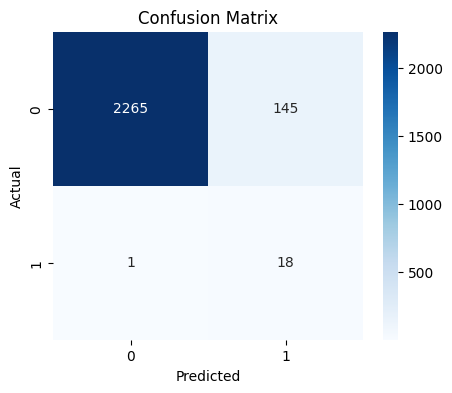

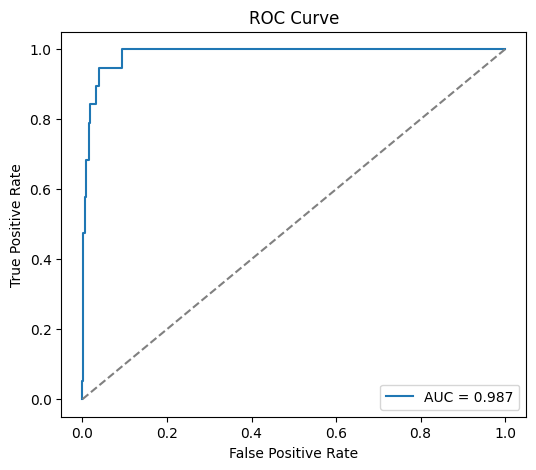

In [25]:
from nba_draft_predictor import evaluate_model, plot_confusion_matrix, plot_roc_curve

# Text-based evaluation
evaluate_model(logreg, X_train, y_train, X_val, y_val)

# Confusion Matrix
y_val_pred = logreg.predict(X_val)
plot_confusion_matrix(y_val, y_val_pred, labels=[0, 1])

# ROC Curve
y_val_proba = logreg.predict_proba(X_val)[:, 1]
plot_roc_curve(y_val, y_val_proba)


In [26]:
from nba_draft_predictor import  make_submission_xlsx

submission = make_submission_xlsx(logreg, X_test, test_df, "submission.xlsx")
submission.head()

submission.xlsx created


,player_id,drafted
0,c6d3ce49-28b6-4756-8061-b2bd68730c52,0.001072
1,24dd0ae2-9d22-4d31-9cb6-c31f58f903b5,0.004059
2,0cf3e822-9446-4285-b7ed-7c19d8e976fe,0.308977
3,b1a88de0-6852-4597-bb92-9164b40758e5,0.008508
4,97c327ce-d051-40f0-9166-1a43557c3c92,0.011268


In [27]:
model_performance_explanations = """
The Logistic Regression model achieved strong AUROC scores on both training (0.985) and validation 
(0.987), indicating that it can effectively separate drafted from non-drafted players. The model 
captured almost all drafted players, with very high recall (0.95), correctly identifying 18 of 19 
cases. However, precision for the drafted class was very low (0.11), meaning many non-drafted players 
were incorrectly classified as drafted (145 false positives). This trade-off reflects the impact of 
class imbalance and the model’s linear decision boundary. While recall is valuable in ensuring that 
true prospects are not overlooked, the low precision would result in significant scouting inefficiency. 
Overall, Logistic Regression confirms that player attributes are predictive, but its performance on 
the minority class is limited, motivating the use of more flexible non-linear models like Random 
Forest or LightGBM.
"""

In [28]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [29]:
business_impacts_explanations = """
The Logistic Regression model shows that player statistics are predictive, achieving excellent AUROC 
and very high recall for drafted players (0.95). This means that almost no true prospects are missed, 
which is valuable for scouting since overlooking talent is highly costly. However, the very low precision 
(0.11) results in a large number of false positives, where many non-drafted players are incorrectly 
flagged as potential draftees. From a business perspective, this would lead to wasted scouting resources, 
time, and effort spent on players who ultimately will not be drafted. While the high recall aligns with 
the objective of ensuring valuable prospects are captured, the inefficiency created by low precision makes 
the model less practical on its own. Therefore, Logistic Regression serves as a useful baseline but requires 
more advanced models to reduce false positives and better balance scouting workload with accuracy.
"""

In [30]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [31]:
experiment_outcome = "Hypothesis Partially Confirmed"

In [32]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [33]:
experiment_results_explanations = """
The Logistic Regression experiment achieved high AUROC (0.987) and recall (0.95), confirming that 
player statistics are predictive and that most true prospects can be identified. However, very low 
precision (0.11) means many false positives, making the approach inefficient for deployment. This 
suggests further experimentation is needed with non-linear models such as Random Forest or LightGBM 
to improve precision while maintaining recall.
"""

In [34]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)

In [40]:
import joblib
import os
# Save directly into repo-level models folder
joblib.dump(logreg, "../../models/logistic_regression_model.pkl")




['../../models/logistic_regression_model.pkl']

In [41]:

print(os.getcwd())


C:\Users\prana\advmla_assignment_1\notebooks\Pranav Sathyababu


In [42]:
print(os.listdir(".."))          
print(os.listdir("../../models"))     


['.gitkeep', '36120-25SP-AT1-group24_14121545-experiment1_LR.ipynb', 'Ashley Wang', 'ManhTuan_Nguyen', 'Pranav Sathyababu', 'Weishu Sun']
['.gitkeep', 'best_model_25721325.pkl', 'best_model_25739083.pkl', 'best_model_smote_lg_14121545.pkl', 'logistic_regression_model.pkl']
